In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries installed successfully!")

All libraries installed successfully!


C:\Users\Jangyaseni Dwibedi\AppData\Local\Temp\ipykernel_20268\4292774097.py:18: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])



Missing Values:

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Dataset Information:

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64     

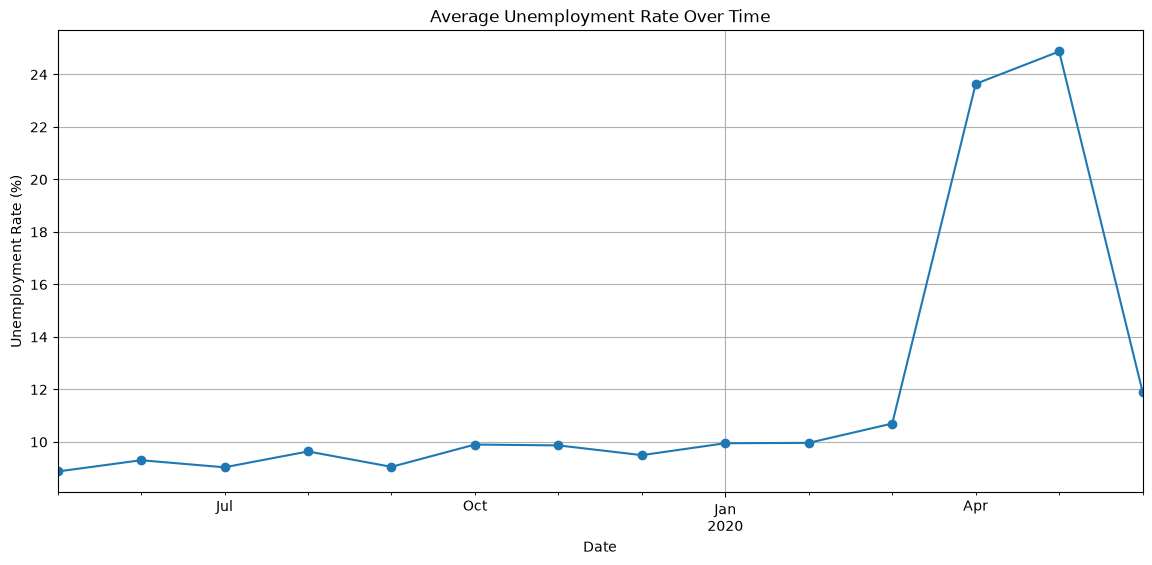

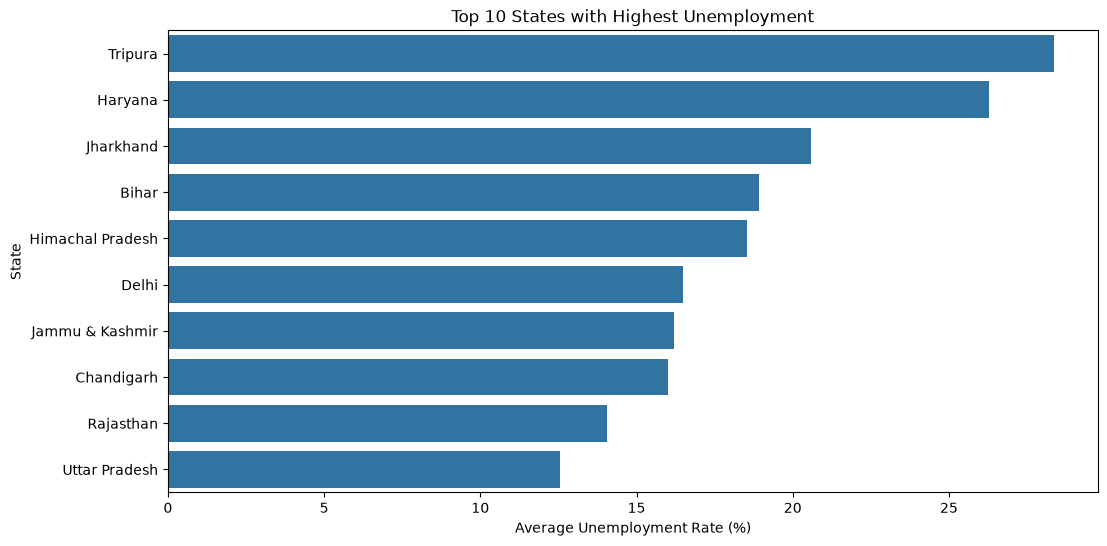

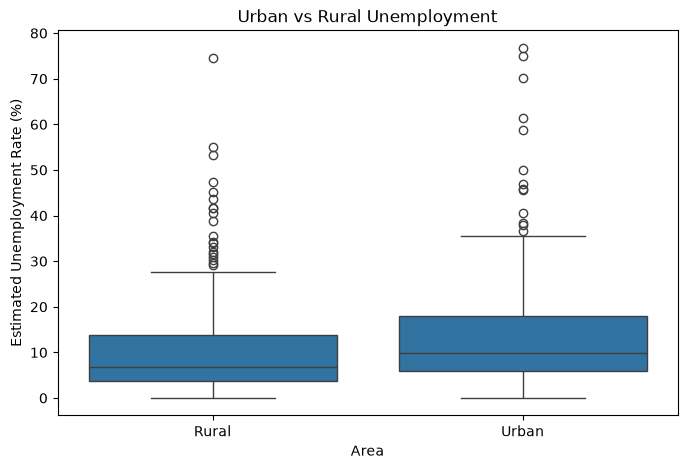


Average Unemployment Before COVID:
9.51

Average Unemployment During COVID:
17.77


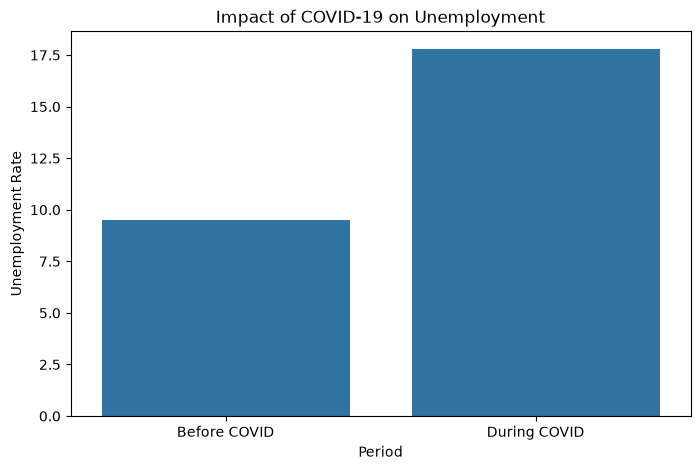

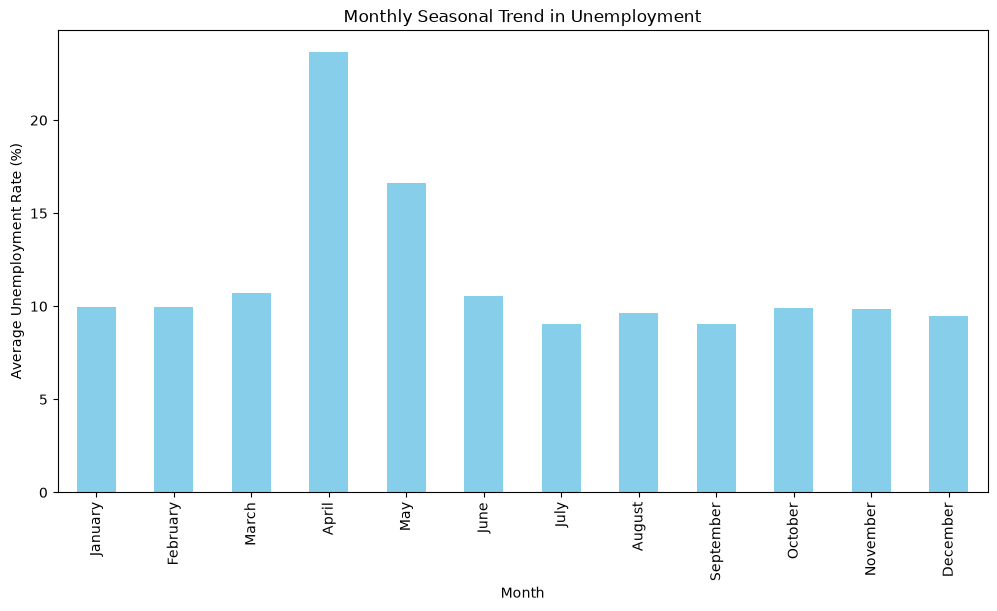

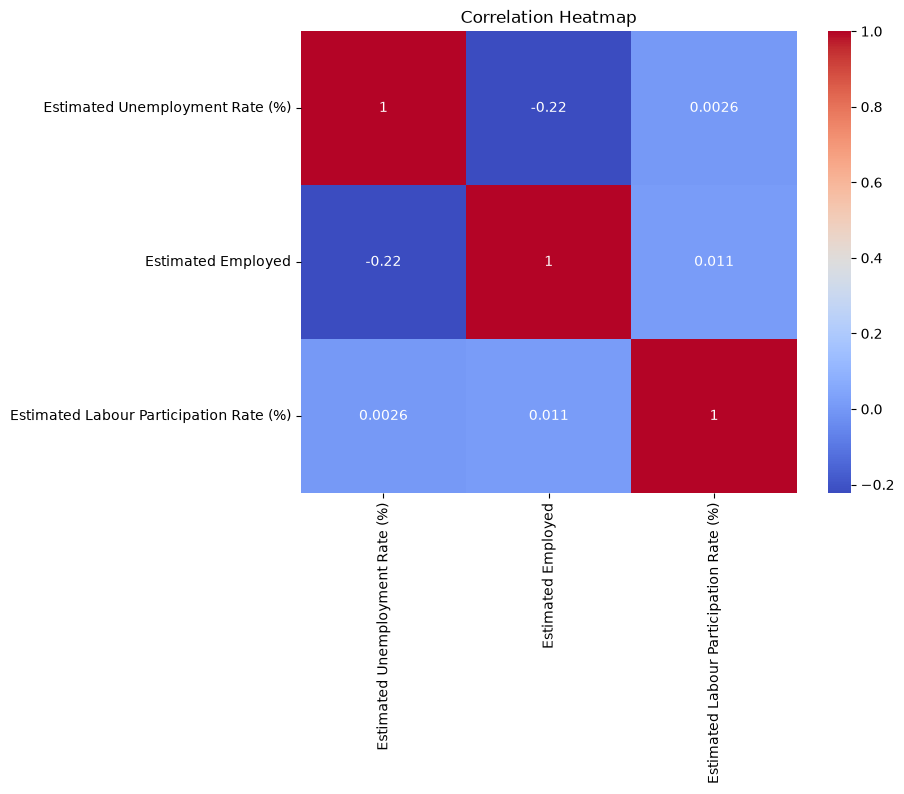

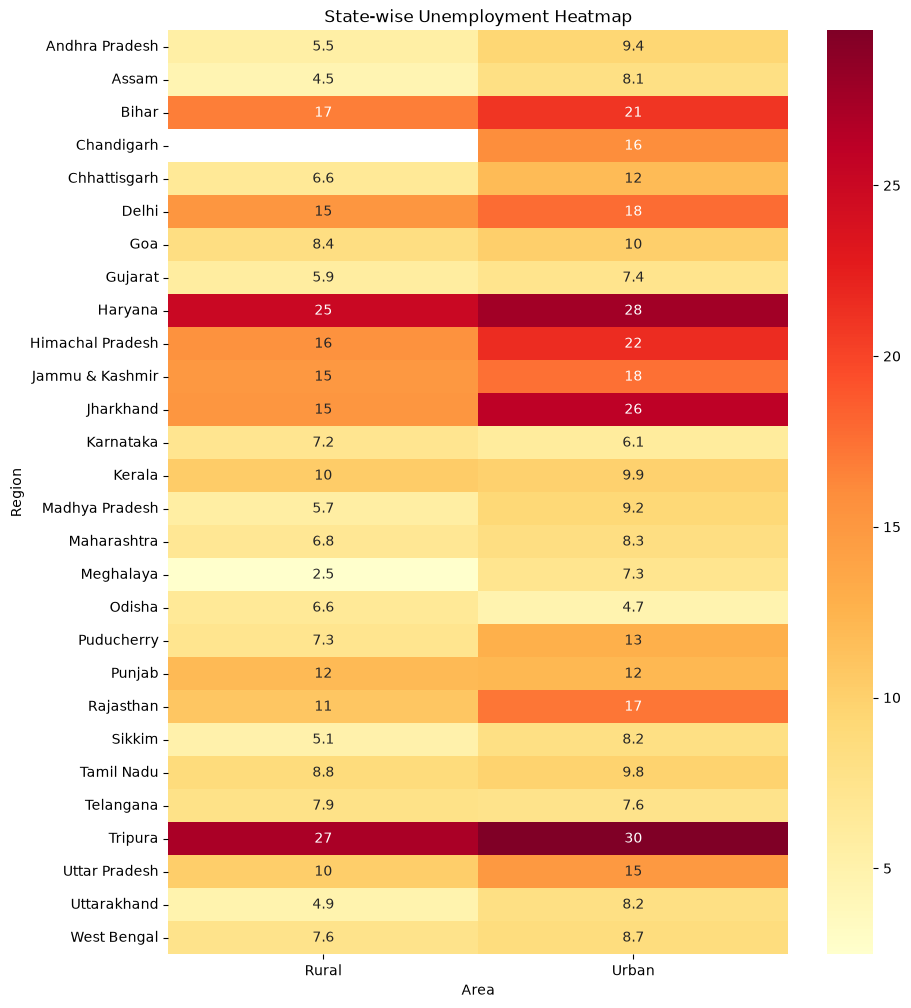


===== KEY INSIGHTS =====
1. Average unemployment rate: 11.79 %
2. COVID period showed a significant increase in unemployment.
3. Some states consistently recorded higher unemployment.
4. Urban and Rural unemployment patterns differ.
5. Seasonal fluctuations can be observed across months.
6. Labour participation rate influences unemployment trends.


In [3]:
# ==================================================
# UNEMPLOYMENT ANALYSIS IN INDIA
# ==================================================
# -----------------------------------------------
# Load Dataset
# -----------------------------------------------

df = pd.read_csv("Unemployment in India.csv")

# -----------------------------------------------
# Data Cleaning
# -----------------------------------------------

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Remove missing values
df.dropna(inplace=True)

# Display basic information
print("\nDataset Information:\n")
print(df.info())

print("\nFirst Five Rows:\n")
print(df.head())

# -----------------------------------------------
# Exploratory Data Analysis
# -----------------------------------------------

print("\nStatistical Summary:\n")
print(df.describe())

# Average unemployment rate
avg_unemployment = df['Estimated Unemployment Rate (%)'].mean()

print("\nAverage Unemployment Rate:")
print(round(avg_unemployment,2), "%")

# -----------------------------------------------
# Monthly Unemployment Trend
# -----------------------------------------------

monthly_unemployment = df.groupby('Date')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(14,6))
monthly_unemployment.plot(marker='o')

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# -----------------------------------------------
# Top 10 States with Highest Unemployment
# -----------------------------------------------

state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x=state_unemployment.head(10).values,
    y=state_unemployment.head(10).index
)

plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

# -----------------------------------------------
# Urban vs Rural Comparison
# -----------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment")
plt.show()

# -----------------------------------------------
# COVID-19 Impact Analysis
# -----------------------------------------------

# Before COVID
before_covid = df[df['Date'] < '2020-03-01']

# During COVID
during_covid = df[df['Date'] >= '2020-03-01']

before_avg = before_covid[
    'Estimated Unemployment Rate (%)'
].mean()

during_avg = during_covid[
    'Estimated Unemployment Rate (%)'
].mean()

print("\nAverage Unemployment Before COVID:")
print(round(before_avg,2))

print("\nAverage Unemployment During COVID:")
print(round(during_avg,2))

# Visualization

covid_data = pd.DataFrame({
    'Period':['Before COVID','During COVID'],
    'Unemployment Rate':[before_avg,during_avg]
})

plt.figure(figsize=(8,5))

sns.barplot(
    x='Period',
    y='Unemployment Rate',
    data=covid_data
)

plt.title("Impact of COVID-19 on Unemployment")
plt.show()

# -----------------------------------------------
# Monthly Seasonal Trend
# -----------------------------------------------

df['Month'] = df['Date'].dt.month_name()

monthly_pattern = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_pattern = monthly_pattern.reindex(month_order)

plt.figure(figsize=(12,6))

monthly_pattern.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Monthly Seasonal Trend in Unemployment")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

# -----------------------------------------------
# Correlation Analysis
# -----------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
       ]].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# -----------------------------------------------
# State-wise Heatmap
# -----------------------------------------------

pivot_table = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Area',
    aggfunc='mean'
)

plt.figure(figsize=(10,12))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='YlOrRd'
)

plt.title("State-wise Unemployment Heatmap")
plt.show()

# -----------------------------------------------
# Final Insights
# -----------------------------------------------

print("\n===== KEY INSIGHTS =====")

print("1. Average unemployment rate:",
      round(avg_unemployment,2),"%")

print("2. COVID period showed a significant increase in unemployment.")

print("3. Some states consistently recorded higher unemployment.")

print("4. Urban and Rural unemployment patterns differ.")

print("5. Seasonal fluctuations can be observed across months.")

print("6. Labour participation rate influences unemployment trends.")

In [ ]:
venv\Scripts\activate.bat

SyntaxError: unexpected character after line continuation character (946491165.py, line 1)